In [1]:
# Dataset Creation Imports
import glob
import pandas as pd
import yaml
import itertools
from pymatgen.core import Structure, Element
import torch
import torch.nn as nn
from torch.optim import Adam
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn.conv import TransformerConv
from torch_geometric.nn.glob import global_mean_pool
import numpy as np
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GATConv
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.nn import DimeNet
import math
np.math = math
import torch_sparse
from torch_sparse import SparseTensor
import torch_scatter
import torch_cluster
import torch_spline_conv
from torch_geometric.nn import GlobalAttention
from torch_geometric.nn import MessagePassing

In [2]:
class GNNModel(nn.Module):
    def __init__(self, n_atom_features, n_output_freqs, edge_dim=1):
        super().__init__()
        hidden_channels = 16

        self.embedding = TransformerConv(
            n_atom_features, hidden_channels, edge_dim=edge_dim
        )
        self.convs = nn.ModuleList(
            [
                TransformerConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
                for _ in range(2)
            ]
        )

        self.bn_embedding = nn.BatchNorm1d(hidden_channels)
        self.bns = nn.ModuleList(
            [nn.BatchNorm1d(hidden_channels) for _ in range(len(self.convs))]
        )

        self.global_mlp = nn.Sequential(nn.Linear(1, 1), nn.ReLU(), nn.BatchNorm1d(1))
        self.u_scale_factor = nn.Parameter(torch.ones(1))

        temp = 2048
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels + 1, temp // 4),
            nn.BatchNorm1d(temp // 4),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(temp // 4, temp // 2),
            nn.BatchNorm1d(temp // 2),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(temp // 2, temp // 1),
            nn.BatchNorm1d(temp // 1),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(temp // 1, n_output_freqs),
        )
        self.scale_factor = nn.Parameter(torch.ones(1))
        gate_nn = nn.Sequential(nn.Linear(hidden_channels, 1), nn.Sigmoid())
        self.pool = GlobalAttention(gate_nn=gate_nn)

    def forward(self, data):
        x, edge_index, edge_attr, batch, u, pos = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
            data.pos,
        )

        x = self.embedding(x, edge_index, edge_attr)
        x = self.bn_embedding(x)
        x = x.tanh()

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = x.tanh()

        pooled_x = self.pool(x, batch)

        combined_vector = torch.cat(
            [self.scale_factor * pooled_x, self.u_scale_factor * u],
            dim=1,
        )

        output = self.mlp(combined_vector)

        return output

In [3]:
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 1000
RANDOM_SEED = 555

dataset_path = 'dataset.pt'

dataset = torch.load(dataset_path, weights_only=False)
print(f"Successfully loaded dataset with {len(dataset)} graphs from {dataset_path}")

Successfully loaded dataset with 358 graphs from dataset.pt


In [ ]:
points_num = 5
band_num = 3

for i in range(points_num*band_num):
    feat_dim = dataset[0].x.size(1)
    new_node_feat = torch.zeros((1, feat_dim), dtype=dataset[0].x.dtype)
    dataset[0].x = torch.cat([dataset[0].x, new_node_feat], dim=0)

    for j in range(8):
        dataset[0].edge_index = torch.cat([dataset[0].edge_index, torch.tensor([[j],[8+i]])], dim=1)

        dataset[0].edge_attr = torch.cat([dataset[0].edge_attr, torch.tensor([[0.0]])])

for j in range(3):
    for i in range(4):
        dataset[0].edge_index = torch.cat([dataset[0].edge_index, torch.tensor([[8+i +j*points_num],[9+i + j*points_num]])], dim=1)
        dataset[0].edge_index = torch.cat([dataset[0].edge_index, torch.tensor([[9+i + j*points_num],[8+i + j*points_num]])], dim=1)

        dataset[0].edge_attr = torch.cat([dataset[0].edge_attr, torch.tensor([[0.0]])])
        dataset[0].edge_attr = torch.cat([dataset[0].edge_attr, torch.tensor([[0.0]])])

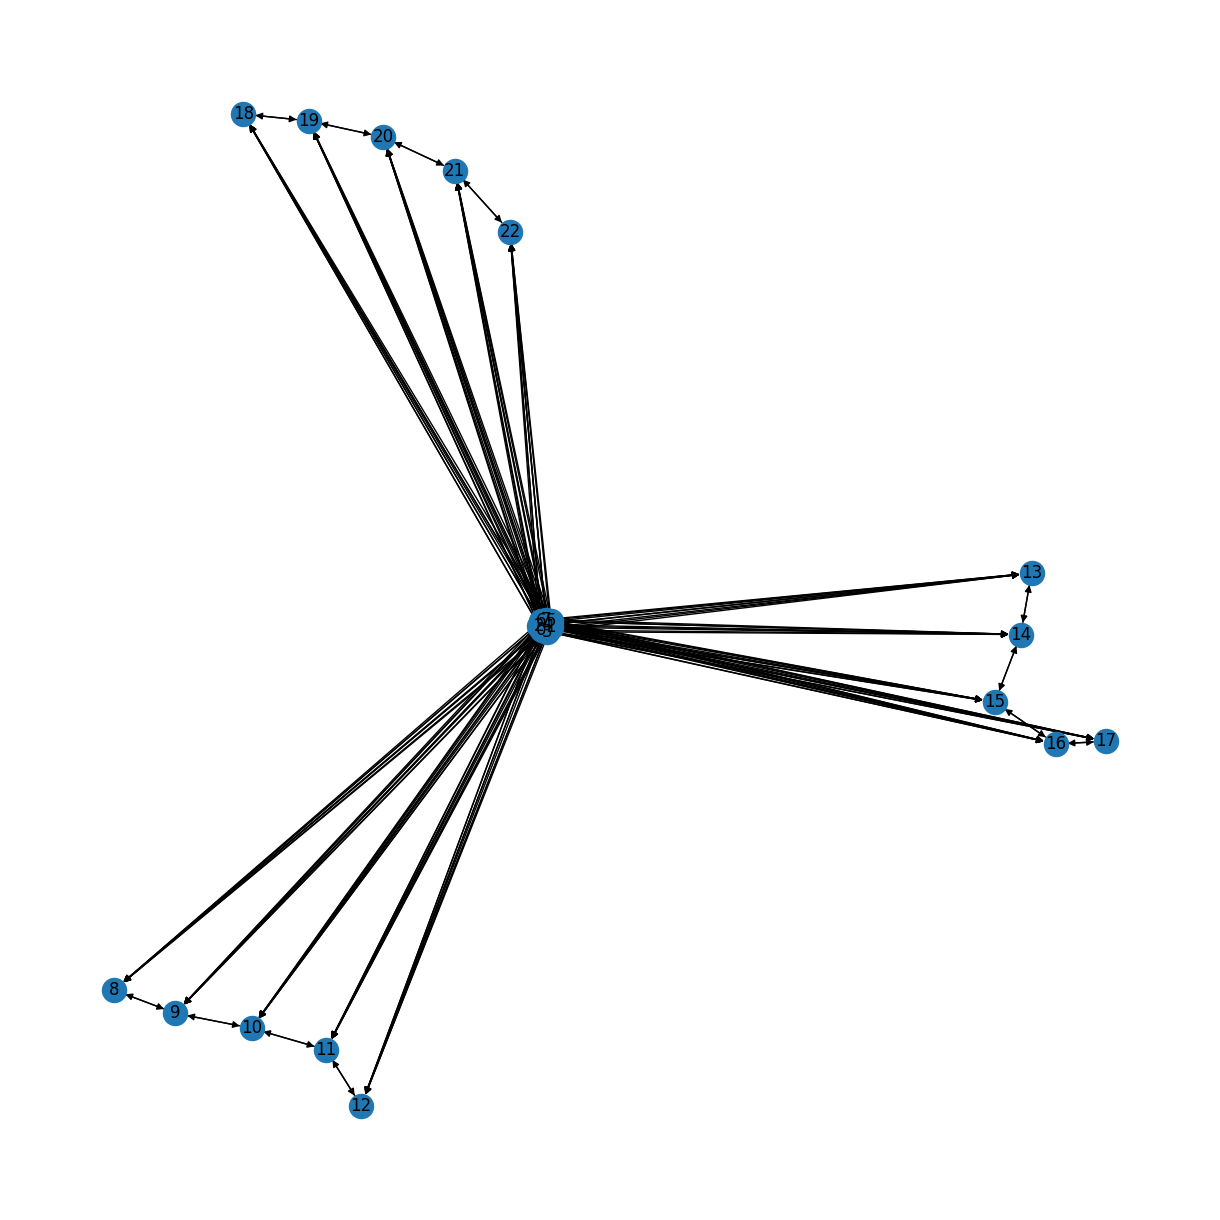

In [139]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

sample = dataset[0]
G = to_networkx(sample, node_attrs=["x"], edge_attrs=["edge_attr"])

plt.figure(figsize=(12, 12))
nx.draw(G, with_labels=True, node_size=300)
plt.show()

In [88]:
sample.edge_index.shape

torch.Size([2, 57])

In [95]:
sample.edge_attr = torch.cat([sample.edge_attr, torch.tensor([[0.0]])])

In [96]:
sample.edge_attr.shape

torch.Size([57, 1])

In [83]:
sample.edge_index = torch.cat([sample.edge_index, torch.tensor([[8],[1]])], dim=1)

In [84]:
sample.edge_index

tensor([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
         3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
         6, 7, 7, 7, 7, 7, 7, 7, 8],
        [1, 2, 3, 4, 5, 6, 7, 0, 2, 3, 4, 5, 6, 7, 0, 1, 3, 4, 5, 6, 7, 0, 1, 2,
         4, 5, 6, 7, 0, 1, 2, 3, 5, 6, 7, 0, 1, 2, 3, 4, 6, 7, 0, 1, 2, 3, 4, 5,
         7, 0, 1, 2, 3, 4, 5, 6, 1]])

In [15]:
import phonopy
import numpy as np

# Load structure and force constants from phonopy YAML file with 5x5x1 supercell
ph = phonopy.load(phonopy_yaml="umlip/W4Tl2C2.yaml", 
                  supercell_matrix=[[5, 0, 0], [0, 5, 0], [0, 0, 1]])

# Define high-symmetry path for hexagonal system
G  = [0.0, 0.0, 0.0]
M  = [0.5, 0.0, 0.0]
K  = [1/3, 1/3, 0.0]
A  = [0.0, 0.0, 0.5]
L  = [0.5, 0.0, 0.5]
H  = [1/3, 1/3, 0.5]

def seg(p, q, n=51):
    return np.linspace(p, q, n)

bands = [
    seg(G, M), seg(M, K), seg(K, G),
    seg(G, A), seg(A, L), seg(L, H), seg(H, A)
]
labels = [r'$\Gamma$', 'M', 'K', r'$\Gamma$', 'A', 'L', 'H', 'A']

# Run band structure calculation
ph.run_band_structure(bands, labels=labels)

# Write to band.yaml using the correct method
ph.write_yaml_band_structure()
print("band.yaml written successfully!")

band.yaml written successfully!


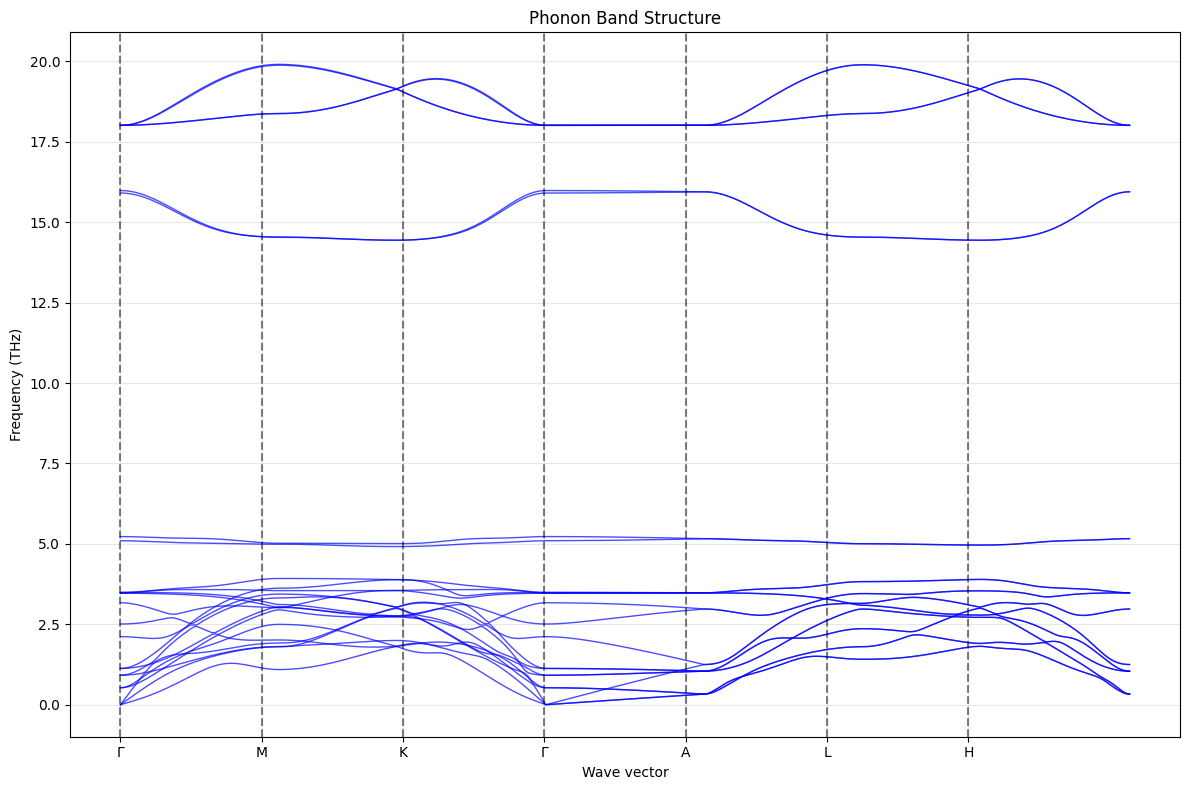

Plotted phonon dispersion with 24 bands and 357 q-points
Figure saved as 'phonon_dispersion.png'


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import yaml

# Read the band.yaml file
with open('umlip/predicted-W4Tl2C2.yaml', 'r') as f:
    band_data = yaml.safe_load(f)

# Extract phonon band data
phonon = band_data['phonon']

# Prepare data for plotting
distances = []
frequencies = []
segment_points = []

current_distance = 0.0
distances.append(current_distance)

for i, point in enumerate(phonon):
    q_point = point['q-position']
    freqs = [band['frequency'] for band in point['band']]
    frequencies.append(freqs)
    
    # Calculate distance for next point
    if i < len(phonon) - 1:
        next_q = phonon[i+1]['q-position']
        # Simple distance calculation (you might want to use proper reciprocal lattice)
        dist = np.sqrt(sum([(next_q[j] - q_point[j])**2 for j in range(3)]))
        current_distance += dist
        distances.append(current_distance)

# Convert to numpy arrays
distances = np.array(distances)
frequencies = np.array(frequencies)

# Plot the band structure
plt.figure(figsize=(12, 8))

# Plot all bands
for band_idx in range(frequencies.shape[1]):
    plt.plot(distances, frequencies[:, band_idx], 'b-', linewidth=1, alpha=0.7)

plt.xlabel('Wave vector')
plt.ylabel('Frequency (THz)')
plt.title('Phonon Band Structure')
plt.grid(True, alpha=0.3)

# Add high-symmetry point labels if available
if 'segment_nqpoint' in band_data:
    segment_points = band_data['segment_nqpoint']
    labels = [r'$\Gamma$', 'M', 'K', r'$\Gamma$', 'A', 'L', 'H', 'A']
    
    current_pos = 0
    tick_positions = [current_pos]
    
    for npoints in segment_points[:-1]:  # Skip last segment
        current_pos += npoints - 1  # -1 because segments share endpoints
        tick_positions.append(current_pos)
    
    plt.xticks(np.array(tick_positions) * distances[-1] / len(distances), labels[:len(tick_positions)])
    
    # Add vertical lines at high-symmetry points
    for pos in tick_positions:
        plt.axvline(x=pos * distances[-1] / len(distances), color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('phonon_dispersion.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Plotted phonon dispersion with {frequencies.shape[1]} bands and {len(distances)} q-points")
print("Figure saved as 'phonon_dispersion.png'")

Reading main-band.yaml (ground truth)...
Reading band.yaml (neural network prediction)...
Reading band.yaml (neural network prediction)...

📊 Evaluation Metrics:
RMSE: 0.4373 THz
MAE:  0.3412 THz
R^2:  0.9955

📊 Evaluation Metrics:
RMSE: 0.4373 THz
MAE:  0.3412 THz
R^2:  0.9955


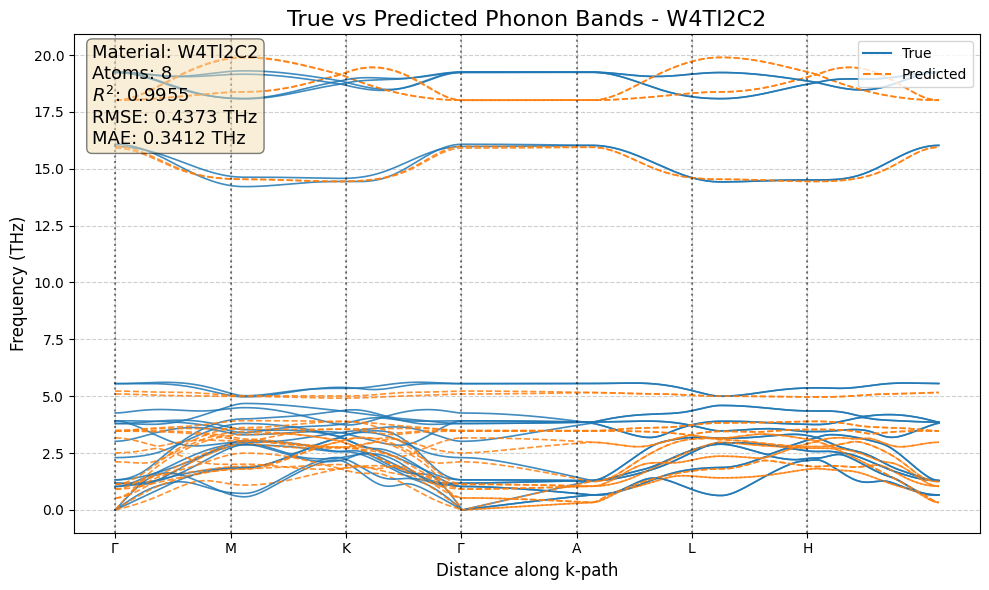


📈 Additional Statistics:
Max absolute error: 1.2400 THz
Min absolute error: 0.0001 THz
Std of errors: 0.3702 THz
Number of bands compared: 24
Number of q-points compared: 357
Figure saved as 'phonon_comparison.png'


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import yaml
from collections import OrderedDict
from matplotlib.lines import Line2D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def read_band_data(filename):
    """Read band data from YAML file and extract frequencies"""
    with open(filename, 'r') as f:
        band_data = yaml.safe_load(f)
    
    phonon = band_data['phonon']
    distances = []
    frequencies = []
    
    current_distance = 0.0
    distances.append(current_distance)
    
    for i, point in enumerate(phonon):
        q_point = point['q-position']
        freqs = [band['frequency'] for band in point['band']]
        frequencies.append(freqs)
        
        # Calculate distance for next point
        if i < len(phonon) - 1:
            next_q = phonon[i+1]['q-position']
            dist = np.sqrt(sum([(next_q[j] - q_point[j])**2 for j in range(3)]))
            current_distance += dist
            distances.append(current_distance)
    
    return np.array(distances), np.array(frequencies), band_data

def build_composition(points):
    """Return chemical formula string preserving first occurrence order."""
    composition_counts = OrderedDict()
    for pt in points:
        symbol = pt['symbol'].strip()
        composition_counts[symbol] = composition_counts.get(symbol, 0) + 1
    return ''.join(
        f"{symbol}{count if count > 1 else ''}" for symbol, count in composition_counts.items()
    )

# Read both band structure files
print("Reading main-band.yaml (ground truth)...")
distances_true, frequencies_true, band_data_true = read_band_data('umlip/main-W4Tl2C2.yaml')

print("Reading band.yaml (neural network prediction)...")
distances_pred, frequencies_pred, band_data_pred = read_band_data('umlip/predicted-W4Tl2C2.yaml')

# Ensure both have same dimensions
min_points = min(len(frequencies_true), len(frequencies_pred))
min_bands = min(frequencies_true.shape[1], frequencies_pred.shape[1])

frequencies_true = frequencies_true[:min_points, :min_bands]
frequencies_pred = frequencies_pred[:min_points, :min_bands]
distances_true = distances_true[:min_points]
distances_pred = distances_pred[:min_points]

# Calculate metrics
true_flat = frequencies_true.flatten()
pred_flat = frequencies_pred.flatten()
rmse = np.sqrt(mean_squared_error(true_flat, pred_flat))
mae = mean_absolute_error(true_flat, pred_flat)
r2 = r2_score(true_flat, pred_flat)

print("\n📊 Evaluation Metrics:")
print(f"RMSE: {rmse:.4f} THz")
print(f"MAE:  {mae:.4f} THz")
print(f"R^2:  {r2:.4f}")

# Composition information from ground-truth structure
composition_str = build_composition(band_data_true.get('points', []))
num_atoms = len(band_data_true.get('points', []))

# Determine shared y-limits
ymin = min(np.min(frequencies_true), np.min(frequencies_pred)) - 1.0
ymax = max(np.max(frequencies_true), np.max(frequencies_pred)) + 1.0

# Plot comparison - styled like reference
fig, ax = plt.subplots(figsize=(10, 6))

for band_idx in range(min_bands):
    ax.plot(distances_true, frequencies_true[:, band_idx], lw=1.2, color='tab:blue', alpha=0.85)
    ax.plot(distances_pred, frequencies_pred[:, band_idx], lw=1.2, color='tab:orange', alpha=0.85, linestyle='--')

ax.set_title(f'True vs Predicted Phonon Bands - {composition_str}', fontsize=16)
ax.set_xlabel('Distance along k-path', fontsize=12)
ax.set_ylabel('Frequency (THz)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(ymin, ymax)

# High-symmetry labels
if 'segment_nqpoint' in band_data_true:
    segment_points = band_data_true['segment_nqpoint']
    labels = [r'$\Gamma$', 'M', 'K', r'$\Gamma$', 'A', 'L', 'H', 'A']
    current_pos = 0
    tick_positions = [current_pos]
    for npoints in segment_points[:-1]:
        current_pos += npoints - 1
        tick_positions.append(current_pos)
    scaled_ticks = np.array(tick_positions) * distances_true[-1] / len(distances_true)
    ax.set_xticks(scaled_ticks)
    ax.set_xticklabels(labels[:len(tick_positions)])
    for pos in scaled_ticks:
        ax.axvline(x=pos, color='k', linestyle=':', alpha=0.5)

# Legend using proxy artists
legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=1.5, label='True'),
    Line2D([0], [0], color='tab:orange', lw=1.5, linestyle='--', label='Predicted'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

# Metrics annotation box
metrics_text = (
    f"Material: {composition_str}\n"
    f"Atoms: {num_atoms}\n"
    f"$R^2$: {r2:.4f}\n"
    f"RMSE: {rmse:.4f} THz\n"
    f"MAE: {mae:.4f} THz"
)
ax.text(
    0.02,
    0.98,
    metrics_text,
    transform=ax.transAxes,
    fontsize=13,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5),
)

plt.tight_layout()
plt.savefig('phonon_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional statistics
frequency_diff = frequencies_pred - frequencies_true
print("\n📈 Additional Statistics:")
print(f"Max absolute error: {np.max(np.abs(frequency_diff)):.4f} THz")
print(f"Min absolute error: {np.min(np.abs(frequency_diff)):.4f} THz")
print(f"Std of errors: {np.std(frequency_diff):.4f} THz")
print(f"Number of bands compared: {min_bands}")
print(f"Number of q-points compared: {min_points}")
print("Figure saved as 'phonon_comparison.png'")